In [2]:
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

# Load Shiv's clean pickles
with open('../data/processed/train_clean.pkl', 'rb') as f:
    train = pickle.load(f)
with open('../data/processed/test_clean.pkl', 'rb') as f:
    test = pickle.load(f)

y = train['TARGET'].values
X = train.drop(columns=['TARGET', 'ID']).values
X_test = test.drop(columns=['ID']).values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('X_test shape:', X_test.shape)
print('Dissatisfied rate:', y.mean().round(4))
print('✅ Data loaded successfully')

X shape: (76020, 95)
y shape: (76020,)
X_test shape: (75818, 95)
Dissatisfied rate: 0.0396
✅ Data loaded successfully


In [4]:
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

print('✅ Model definition ready')
print(build_mlp(95).summary())

✅ Model definition ready


2026-05-01 10:48:47.630000: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-01 10:48:47.630095: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-01 10:48:47.630113: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-01 10:48:47.630160: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-01 10:48:47.630181: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,585 (264.00 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 896 (3.50 KB)

None


In [5]:
# Class weight to handle 24:1 imbalance
class_weight = {0: 1, 1: 24}

# CV setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds   = np.zeros(len(X))
test_preds  = np.zeros(len(X_test))
fold_aucs   = []
histories   = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'\n=== Fold {fold+1}/5 ===')
    
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    # StandardScaler — fit on fold train only
    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    X_te  = scaler.transform(X_test)
    
    # Fresh model each fold
    model = build_mlp(input_dim=X_tr.shape[1])
    
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=10,
            restore_best_weights=True,
            mode='max'
        )
    ]
    
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=512,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )
    
    histories.append(history)
    
    val_pred  = model.predict(X_val, verbose=0).flatten()
    test_pred = model.predict(X_te, verbose=0).flatten()
    
    oof_preds[val_idx] = val_pred
    test_preds += test_pred / 5
    
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_aucs.append(fold_auc)
    print(f'Fold {fold+1} AUC: {fold_auc:.5f}')

print(f'\n=== FINAL RESULTS ===')
print(f'Fold AUCs : {[round(a,5) for a in fold_aucs]}')
print(f'Mean CV AUC : {np.mean(fold_aucs):.5f}')
print(f'Std CV AUC  : {np.std(fold_aucs):.5f}')
print(f'OOF AUC     : {roc_auc_score(y, oof_preds):.5f}')


=== Fold 1/5 ===
Epoch 1/100


2026-05-01 10:49:34.421956: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - auc: 0.7596 - loss: 1.1492 - val_auc: 0.8045 - val_loss: 0.5188
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - auc: 0.8072 - loss: 1.0316 - val_auc: 0.8118 - val_loss: 0.5299
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc: 0.8134 - loss: 1.0136 - val_auc: 0.8118 - val_loss: 0.5783
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc: 0.8197 - loss: 0.9951 - val_auc: 0.8131 - val_loss: 0.5753
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc: 0.8233 - loss: 0.9874 - val_auc: 0.8117 - val_loss: 0.5692
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc: 0.8264 - loss: 0.9790 - val_auc: 0.8132 - val_loss: 0.5607
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc: 0.8316 - loss: 0.9666 - val_auc: 0.8145 - val_loss: 0.5537
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc: 0.8314 - loss: 0.9644 - val_auc: 0.8134 - val_loss: 0.5597
Epoch 9/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/ste

In [6]:
# IMPROVED MLP — pushing for best AUC

def build_mlp_v2(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),
        
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

# Stronger class weight
class_weight_v2 = {0: 1, 1: 48}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_v2  = np.zeros(len(X))
test_preds_v2 = np.zeros(len(X_test))
fold_aucs_v2  = []
histories_v2  = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'\n=== Fold {fold+1}/5 ===')
    
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    X_te  = scaler.transform(X_test)
    
    model = build_mlp_v2(input_dim=X_tr.shape[1])
    
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=20,
            restore_best_weights=True,
            mode='max'
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc',
            factor=0.5,
            patience=7,
            mode='max',
            verbose=1
        )
    ]
    
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=256,
        class_weight=class_weight_v2,
        callbacks=callbacks,
        verbose=1
    )
    
    histories_v2.append(history)
    
    val_pred  = model.predict(X_val, verbose=0).flatten()
    test_pred = model.predict(X_te, verbose=0).flatten()
    
    oof_preds_v2[val_idx] = val_pred
    test_preds_v2 += test_pred / 5
    
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_aucs_v2.append(fold_auc)
    print(f'Fold {fold+1} AUC: {fold_auc:.5f}')

print(f'\n=== V2 RESULTS ===')
print(f'Fold AUCs : {[round(a,5) for a in fold_aucs_v2]}')
print(f'Mean CV AUC : {np.mean(fold_aucs_v2):.5f}')
print(f'Std CV AUC  : {np.std(fold_aucs_v2):.5f}')
print(f'OOF AUC     : {roc_auc_score(y, oof_preds_v2):.5f}')
print(f'\nBaseline v1 : {np.mean(fold_aucs):.5f}')
print(f'Improved v2 : {np.mean(fold_aucs_v2):.5f}')
print(f'Difference  : {np.mean(fold_aucs_v2) - np.mean(fold_aucs):+.5f}')


=== Fold 1/5 ===
Epoch 1/200
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - auc: 0.7724 - loss: 1.5551 - val_auc: 0.8064 - val_loss: 0.8201 - learning_rate: 0.0010
Epoch 2/200
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - auc: 0.8039 - loss: 1.4377 - val_auc: 0.8108 - val_loss: 0.8133 - learning_rate: 0.0010
Epoch 3/200
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - auc: 0.8128 - loss: 1.3963 - val_auc: 0.8125 - val_loss: 0.8491 - learning_rate: 0.0010
Epoch 4/200
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - auc: 0.8200 - loss: 1.3735 - val_auc: 0.8134 - val_loss: 0.8217 - learning_rate: 0.0010
Epoch 5/200
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - auc: 0.8226 - loss: 1.3652 - val_auc: 0.8112 - val_loss: 0.8216 - learning_rate: 0.0010
Epoch 6/200
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - auc: 0.8246 - loss: 1.3496 - val_auc: 0.8143 - val_loss: 0.8030 - learning_rate: 0.0010
Epoch 7/200
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - auc: 0.8265 - loss: 1.3435 - val_auc: 0.8155 - val_loss: 0.816

In [7]:
# V3 — Multi-seed averaging with best v1 architecture

SEEDS = [42, 7, 13, 99, 21]

oof_preds_v3  = np.zeros(len(X))
test_preds_v3 = np.zeros(len(X_test))
all_fold_aucs = []

for seed in SEEDS:
    print(f'\n====== SEED {seed} ======')
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_oof   = np.zeros(len(X))
    seed_test  = np.zeros(len(X_test))
    seed_aucs  = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)
        X_te  = scaler.transform(X_test)
        
        model = build_mlp(input_dim=X_tr.shape[1])
        
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_auc',
                patience=10,
                restore_best_weights=True,
                mode='max'
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_auc',
                factor=0.5,
                patience=5,
                mode='max',
                verbose=0
            )
        ]
        
        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=512,
            class_weight={0:1, 1:24},
            callbacks=callbacks,
            verbose=0
        )
        
        val_pred  = model.predict(X_val, verbose=0).flatten()
        test_pred = model.predict(X_te, verbose=0).flatten()
        
        seed_oof[val_idx] = val_pred
        seed_test += test_pred / 5
        
        fold_auc = roc_auc_score(y_val, val_pred)
        seed_aucs.append(fold_auc)
        print(f'  Seed {seed} Fold {fold+1} AUC: {fold_auc:.5f}')
    
    seed_mean = np.mean(seed_aucs)
    all_fold_aucs.append(seed_mean)
    print(f'  Seed {seed} Mean AUC: {seed_mean:.5f}')
    
    # Average across seeds
    oof_preds_v3  += seed_oof / len(SEEDS)
    test_preds_v3 += seed_test / len(SEEDS)

print(f'\n=== V3 MULTI-SEED RESULTS ===')
print(f'Per-seed AUCs : {[round(a,5) for a in all_fold_aucs]}')
print(f'Mean seed AUC : {np.mean(all_fold_aucs):.5f}')
print(f'OOF AUC       : {roc_auc_score(y, oof_preds_v3):.5f}')
print(f'\nBaseline v1   : {np.mean(fold_aucs):.5f}')
print(f'Multi-seed v3 : {roc_auc_score(y, oof_preds_v3):.5f}')
print(f'Difference    : {roc_auc_score(y, oof_preds_v3) - np.mean(fold_aucs):+.5f}')


====== SEED 42 ======
  Seed 42 Fold 1 AUC: 0.81438
  Seed 42 Fold 2 AUC: 0.83255
  Seed 42 Fold 3 AUC: 0.83526
  Seed 42 Fold 4 AUC: 0.82217
  Seed 42 Fold 5 AUC: 0.82542
  Seed 42 Mean AUC: 0.82595

====== SEED 7 ======
  Seed 7 Fold 1 AUC: 0.82968
  Seed 7 Fold 2 AUC: 0.82981
  Seed 7 Fold 3 AUC: 0.82076
  Seed 7 Fold 4 AUC: 0.82832
  Seed 7 Fold 5 AUC: 0.81963
  Seed 7 Mean AUC: 0.82564

====== SEED 13 ======
  Seed 13 Fold 1 AUC: 0.81805
  Seed 13 Fold 2 AUC: 0.84304
  Seed 13 Fold 3 AUC: 0.82135
  Seed 13 Fold 4 AUC: 0.83292
  Seed 13 Fold 5 AUC: 0.81487
  Seed 13 Mean AUC: 0.82604

====== SEED 99 ======
  Seed 99 Fold 1 AUC: 0.82931
  Seed 99 Fold 2 AUC: 0.82691
  Seed 99 Fold 3 AUC: 0.83511
  Seed 99 Fold 4 AUC: 0.81999
  Seed 99 Fold 5 AUC: 0.81598
  Seed 99 Mean AUC: 0.82546

====== SEED 21 ======
  Seed 21 Fold 1 AUC: 0.83296
  Seed 21 Fold 2 AUC: 0.82466
  Seed 21 Fold 3 AUC: 0.82468
  Seed 21 Fold 4 AUC: 0.83220
  Seed 21 Fold 5 AUC: 0.81581
  Seed 21 Mean AUC: 0.82606

=

✅ Best predictions saved


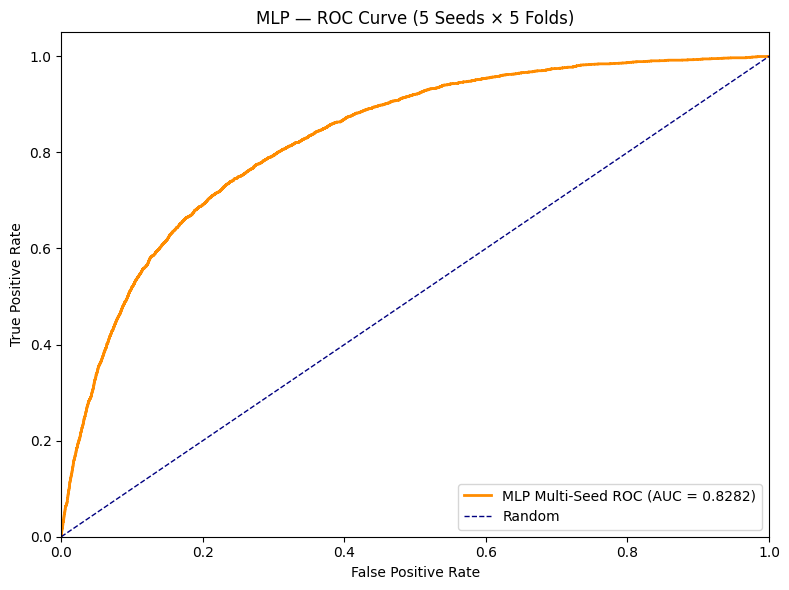

✅ ROC curve saved
✅ Logged to experiments.csv
                                                         0
date                                            2026-05-01
member                                               Madhu
model                                        MLP_multiseed
features                                                95
cv_folds                                                 5
seeds                                                    5
mean_cv_auc                                        0.82583
oof_auc                                            0.82821
architecture                  256-128-64 BatchNorm Dropout
class_weight                                      0:1 1:24
epochs                                                 100
batch_size                                             512
notes         5 seeds x 5 folds averaged — best MLP result


In [9]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from datetime import datetime

# Save best predictions (v3 multi-seed)
os.makedirs('../outputs/oof', exist_ok=True)
np.save('../outputs/oof/mlp_oof_best.npy', oof_preds_v3)
np.save('../outputs/oof/mlp_test_preds_best.npy', test_preds_v3)
print('✅ Best predictions saved')

# ROC Curve
fpr, tpr, _ = roc_curve(y, oof_preds_v3)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'MLP Multi-Seed ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, 
         linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MLP — ROC Curve (5 Seeds × 5 Folds)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/mlp_roc_curve_best.png', dpi=100)
plt.show()
print('✅ ROC curve saved')

# Log to experiments.csv
log = {
    'date': datetime.today().strftime('%Y-%m-%d'),
    'member': 'Madhu',
    'model': 'MLP_multiseed',
    'features': 95,
    'cv_folds': 5,
    'seeds': 5,
    'mean_cv_auc': round(np.mean(all_fold_aucs), 5),
    'oof_auc': round(roc_auc_score(y, oof_preds_v3), 5),
    'architecture': '256-128-64 BatchNorm Dropout',
    'class_weight': '0:1 1:24',
    'epochs': 100,
    'batch_size': 512,
    'notes': '5 seeds x 5 folds averaged — best MLP result'
}

log_df = pd.DataFrame([log])
exp_path = '../experiments.csv'

if os.path.exists(exp_path):
    existing = pd.read_csv(exp_path)
    updated = pd.concat([existing, log_df], ignore_index=True)
else:
    updated = log_df

updated.to_csv(exp_path, index=False)
print('✅ Logged to experiments.csv')
print(log_df.T)

In [11]:
import os

# Create folder if it doesn't exist
os.makedirs('../outputs/submissions', exist_ok=True)

# Create Kaggle submission file
submission = pd.read_csv('../data/raw/test.csv')[['ID']]
submission['TARGET'] = test_preds_v3

submission.to_csv('../outputs/submissions/mlp_submission.csv', index=False)
print('✅ Submission file created')
print(submission.shape)
print(submission.head())

✅ Submission file created
(75818, 2)
   ID    TARGET
0   2  0.528253
1   5  0.618470
2   6  0.054144
3   7  0.213903
4   9  0.059815


In [12]:
import pandas as pd
import pickle

with open('../data/processed/train_clean.pkl', 'rb') as f:
    train_pkl = pickle.load(f)

train_csv = pd.read_csv('../data/processed/clean_train.csv')

pkl_cols = set(train_pkl.drop(columns=['TARGET','ID']).columns)
csv_cols = set(train_csv.drop(columns=['TARGET']).columns)

extra = csv_cols - pkl_cols
missing = pkl_cols - csv_cols

print(f"Extra features in CSV not in pickle: {len(extra)}")
print(sorted(extra))
print(f"\nFeatures in pickle not in CSV: {len(missing)}")
print(sorted(missing))

Extra features in CSV not in pickle: 36
['delta_imp_aport_var13_1y3', 'imp_op_var41_comer_ult1', 'imp_op_var41_comer_ult3', 'imp_op_var41_efect_ult1', 'ind_var12', 'ind_var13_0', 'ind_var13_corto_0', 'ind_var1_0', 'ind_var24', 'ind_var25_cte', 'ind_var26_0', 'ind_var37_0', 'ind_var43_emit_ult1', 'ind_var8', 'ind_var9_cte_ult1', 'ind_var9_ult1', 'num_meses_var13_corto_ult3', 'num_op_var39_comer_ult1', 'num_op_var39_comer_ult3', 'num_op_var41_efect_ult1', 'num_op_var41_efect_ult3', 'num_op_var41_hace3', 'num_op_var41_ult1', 'num_var13', 'num_var13_largo', 'num_var26_0', 'num_var37_med_ult2', 'num_var39_0', 'num_var45_hace2', 'saldo_var13', 'saldo_var13_corto', 'saldo_var13_largo', 'saldo_var26', 'var36_99_flag', 'var38_flag', 'var3_missing']

Features in pickle not in CSV: 15
['imp_op_var39_efect_ult1', 'ind_var13', 'ind_var13_corto', 'num_op_var39_efect_ult1', 'num_op_var39_efect_ult3', 'num_op_var39_hace3', 'num_op_var39_ult1', 'num_var40_0', 'num_var8', 'num_zeros', 'num_zeros_imp', '

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load CSV — 117 features
train_csv = pd.read_csv('../data/processed/clean_train.csv')
test_csv  = pd.read_csv('../data/processed/clean_test.csv')

# Drop delta column — confirmed noise
drop_cols = ['delta_imp_aport_var13_1y3']

y_new = train_csv['TARGET'].values
X_new = train_csv.drop(columns=['TARGET'] + drop_cols, errors='ignore').values
X_test_new = test_csv.drop(columns=drop_cols, errors='ignore').values

print('X shape:', X_new.shape)
print('y shape:', y_new.shape)
print('X_test shape:', X_test_new.shape)

X shape: (76020, 115)
y shape: (76020,)
X_test shape: (75818, 115)


In [15]:
zero_cols = [c for c in train_new.columns if 'zero' in c.lower()]
print(zero_cols)

[]


In [16]:
import pandas as pd
import numpy as np
import pickle

# Load both
with open('../data/processed/train_clean.pkl', 'rb') as f:
    train_pkl = pickle.load(f)
with open('../data/processed/test_clean.pkl', 'rb') as f:
    test_pkl = pickle.load(f)

train_csv = pd.read_csv('../data/processed/clean_train.csv')
test_csv  = pd.read_csv('../data/processed/clean_test.csv')

# Extra cols from CSV that pickle doesn't have (drop delta + TARGET)
drop_cols = ['delta_imp_aport_var13_1y3', 'TARGET']
extra_train = train_csv.drop(columns=[c for c in drop_cols if c in train_csv.columns])
extra_test  = test_csv.drop(columns=[c for c in drop_cols if c in test_csv.columns])

# Keep only columns not already in pickle
pkl_cols = set(train_pkl.columns)
extra_only_train = extra_train[[c for c in extra_train.columns if c not in pkl_cols]]
extra_only_test  = extra_test[[c for c in extra_test.columns if c not in pkl_cols]]

# Combine pickle + extra CSV cols
train_combined = pd.concat([train_pkl.reset_index(drop=True), 
                            extra_only_train.reset_index(drop=True)], axis=1)
test_combined  = pd.concat([test_pkl.reset_index(drop=True), 
                            extra_only_test.reset_index(drop=True)], axis=1)

print('Pickle features:', train_pkl.shape[1]-2)  # minus ID and TARGET
print('Extra CSV features:', extra_only_train.shape[1])
print('Combined train shape:', train_combined.shape)
print('Combined test shape:', test_combined.shape)

Pickle features: 95
Extra CSV features: 35
Combined train shape: (76020, 132)
Combined test shape: (75818, 131)


In [17]:
# Add interaction features using Shiv's engineered columns
for df in [train_combined, test_combined]:
    df['var36_x_var15']       = df['var36'] * df['var15']
    df['var38_x_var15']       = df['var38'] * df['var15']
    df['var15_x_num_zeros']   = df['var15'] * df['num_zeros']
    df['num_zeros_ratio']     = df['num_zeros'] / (df['num_zeros_saldo'] + 1)
    df['var15_squared']       = df['var15'] ** 2
    df['var38_log']           = np.log1p(df['var38'].clip(lower=0))
    df['zeros_saldo_x_var15'] = df['num_zeros_saldo'] * df['var15']

# Prepare X and y
y_v4 = train_combined['TARGET'].values
X_v4 = train_combined.drop(columns=['TARGET', 'ID'], errors='ignore').values
X_test_v4 = test_combined.drop(columns=['ID'], errors='ignore').values

print('X_v4 shape:', X_v4.shape)
print('X_test_v4 shape:', X_test_v4.shape)
print('Features added: 7 interactions')

X_v4 shape: (76020, 137)
X_test_v4 shape: (75818, 137)
Features added: 7 interactions


In [18]:
# V4 — CSV + Pickle combined + interactions, 5 seeds

SEEDS = [42, 7, 13, 99, 21]

oof_preds_v4  = np.zeros(len(X_v4))
test_preds_v4 = np.zeros(len(X_test_v4))
all_fold_aucs_v4 = []

for seed in SEEDS:
    print(f'\n====== SEED {seed} ======')
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_oof  = np.zeros(len(X_v4))
    seed_test = np.zeros(len(X_test_v4))
    seed_aucs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_v4, y_v4)):
        X_tr, X_val = X_v4[train_idx], X_v4[val_idx]
        y_tr, y_val = y_v4[train_idx], y_v4[val_idx]
        
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)
        X_te  = scaler.transform(X_test_v4)
        
        model = build_mlp(input_dim=X_tr.shape[1])
        
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_auc',
                patience=10,
                restore_best_weights=True,
                mode='max'
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_auc',
                factor=0.5,
                patience=5,
                mode='max',
                verbose=0
            )
        ]
        
        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=512,
            class_weight={0:1, 1:24},
            callbacks=callbacks,
            verbose=0
        )
        
        val_pred  = model.predict(X_val, verbose=0).flatten()
        test_pred = model.predict(X_te, verbose=0).flatten()
        
        seed_oof[val_idx] = val_pred
        seed_test += test_pred / 5
        
        fold_auc = roc_auc_score(y_val, val_pred)
        seed_aucs.append(fold_auc)
        print(f'  Seed {seed} Fold {fold+1} AUC: {fold_auc:.5f}')
    
    seed_mean = np.mean(seed_aucs)
    all_fold_aucs_v4.append(seed_mean)
    print(f'  Seed {seed} Mean AUC: {seed_mean:.5f}')
    
    oof_preds_v4  += seed_oof / len(SEEDS)
    test_preds_v4 += seed_test / len(SEEDS)

print(f'\n=== V4 RESULTS ===')
print(f'Per-seed AUCs : {[round(a,5) for a in all_fold_aucs_v4]}')
print(f'Mean seed AUC : {np.mean(all_fold_aucs_v4):.5f}')
print(f'OOF AUC       : {roc_auc_score(y_v4, oof_preds_v4):.5f}')
print(f'\nV3 multi-seed : {roc_auc_score(y, oof_preds_v3):.5f}')
print(f'V4 combined   : {roc_auc_score(y_v4, oof_preds_v4):.5f}')
print(f'Difference    : {roc_auc_score(y_v4, oof_preds_v4) - roc_auc_score(y, oof_preds_v3):+.5f}')


====== SEED 42 ======
  Seed 42 Fold 1 AUC: 0.81719
  Seed 42 Fold 2 AUC: 0.83767
  Seed 42 Fold 3 AUC: 0.83642
  Seed 42 Fold 4 AUC: 0.82398
  Seed 42 Fold 5 AUC: 0.82788
  Seed 42 Mean AUC: 0.82863

====== SEED 7 ======
  Seed 7 Fold 1 AUC: 0.83510
  Seed 7 Fold 2 AUC: 0.83293
  Seed 7 Fold 3 AUC: 0.82413
  Seed 7 Fold 4 AUC: 0.83051
  Seed 7 Fold 5 AUC: 0.82240
  Seed 7 Mean AUC: 0.82901

====== SEED 13 ======
  Seed 13 Fold 1 AUC: 0.81980
  Seed 13 Fold 2 AUC: 0.84409
  Seed 13 Fold 3 AUC: 0.82479
  Seed 13 Fold 4 AUC: 0.83520
  Seed 13 Fold 5 AUC: 0.81941
  Seed 13 Mean AUC: 0.82866

====== SEED 99 ======
  Seed 99 Fold 1 AUC: 0.82995
  Seed 99 Fold 2 AUC: 0.83231
  Seed 99 Fold 3 AUC: 0.83506
  Seed 99 Fold 4 AUC: 0.82401
  Seed 99 Fold 5 AUC: 0.82115
  Seed 99 Mean AUC: 0.82850

====== SEED 21 ======
  Seed 21 Fold 1 AUC: 0.83839
  Seed 21 Fold 2 AUC: 0.83014
  Seed 21 Fold 3 AUC: 0.82443
  Seed 21 Fold 4 AUC: 0.83680
  Seed 21 Fold 5 AUC: 0.81820
  Seed 21 Mean AUC: 0.82959

=

In [19]:
import os

os.makedirs('../outputs/submissions', exist_ok=True)

submission_v4 = pd.read_csv('../data/raw/test.csv')[['ID']]
submission_v4['TARGET'] = test_preds_v4

submission_v4.to_csv('../outputs/submissions/mlp_submission_v4.csv', index=False)
print('✅ V4 submission saved')
print(submission_v4.shape)
print(submission_v4.head())

✅ V4 submission saved
(75818, 2)
   ID    TARGET
0   2  0.534487
1   5  0.627998
2   6  0.043383
3   7  0.152206
4   9  0.053237


In [20]:
# Log V4 to experiments.csv
log_v4 = {
    'date': '2026-05-02',
    'member': 'Madhu',
    'model': 'MLP_v4_combined',
    'features': 137,
    'cv_folds': 5,
    'seeds': 5,
    'mean_cv_auc': round(np.mean(all_fold_aucs_v4), 5),
    'oof_auc': round(roc_auc_score(y_v4, oof_preds_v4), 5),
    'public_lb': 0.83177,
    'private_lb': 0.81618,
    'architecture': '256-128-64 BatchNorm Dropout',
    'class_weight': '0:1 1:24',
    'notes': 'Pickle 95 + CSV extra 35 + 7 interactions = 137 features, 5 seeds x 5 folds'
}

log_df_v4 = pd.DataFrame([log_v4])
existing = pd.read_csv('../experiments.csv')
updated = pd.concat([existing, log_df_v4], ignore_index=True)
updated.to_csv('../experiments.csv', index=False)
print('✅ V4 logged to experiments.csv')

✅ V4 logged to experiments.csv


In [21]:
# V5 — Same as V4 but class_weight 1:36 instead of 1:24
# Goal: better private score by being more conservative

SEEDS = [42, 7, 13, 99, 21]

oof_preds_v5  = np.zeros(len(X_v4))
test_preds_v5 = np.zeros(len(X_test_v4))
all_fold_aucs_v5 = []

for seed in SEEDS:
    print(f'\n====== SEED {seed} ======')
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_oof  = np.zeros(len(X_v4))
    seed_test = np.zeros(len(X_test_v4))
    seed_aucs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_v4, y_v4)):
        X_tr, X_val = X_v4[train_idx], X_v4[val_idx]
        y_tr, y_val = y_v4[train_idx], y_v4[val_idx]
        
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)
        X_te  = scaler.transform(X_test_v4)
        
        model = build_mlp(input_dim=X_tr.shape[1])
        
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_auc',
                patience=10,
                restore_best_weights=True,
                mode='max'
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_auc',
                factor=0.5,
                patience=5,
                mode='max',
                verbose=0
            )
        ]
        
        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=512,
            class_weight={0:1, 1:36},
            callbacks=callbacks,
            verbose=0
        )
        
        val_pred  = model.predict(X_val, verbose=0).flatten()
        test_pred = model.predict(X_te, verbose=0).flatten()
        
        seed_oof[val_idx] = val_pred
        seed_test += test_pred / 5
        
        fold_auc = roc_auc_score(y_val, val_pred)
        seed_aucs.append(fold_auc)
        print(f'  Seed {seed} Fold {fold+1} AUC: {fold_auc:.5f}')
    
    seed_mean = np.mean(seed_aucs)
    all_fold_aucs_v5.append(seed_mean)
    print(f'  Seed {seed} Mean AUC: {seed_mean:.5f}')
    
    oof_preds_v5  += seed_oof / len(SEEDS)
    test_preds_v5 += seed_test / len(SEEDS)

print(f'\n=== V5 RESULTS ===')
print(f'Per-seed AUCs : {[round(a,5) for a in all_fold_aucs_v5]}')
print(f'Mean seed AUC : {np.mean(all_fold_aucs_v5):.5f}')
print(f'OOF AUC       : {roc_auc_score(y_v4, oof_preds_v5):.5f}')
print(f'\nV4 (1:24) OOF : {roc_auc_score(y_v4, oof_preds_v4):.5f}')
print(f'V5 (1:36) OOF : {roc_auc_score(y_v4, oof_preds_v5):.5f}')
print(f'Difference    : {roc_auc_score(y_v4, oof_preds_v5) - roc_auc_score(y_v4, oof_preds_v4):+.5f}')


====== SEED 42 ======
  Seed 42 Fold 1 AUC: 0.81689
  Seed 42 Fold 2 AUC: 0.83449
  Seed 42 Fold 3 AUC: 0.83438
  Seed 42 Fold 4 AUC: 0.82544
  Seed 42 Fold 5 AUC: 0.82662
  Seed 42 Mean AUC: 0.82757

====== SEED 7 ======
  Seed 7 Fold 1 AUC: 0.83636
  Seed 7 Fold 2 AUC: 0.83165
  Seed 7 Fold 3 AUC: 0.82408
  Seed 7 Fold 4 AUC: 0.83025
  Seed 7 Fold 5 AUC: 0.82061
  Seed 7 Mean AUC: 0.82859

====== SEED 13 ======
  Seed 13 Fold 1 AUC: 0.81770
  Seed 13 Fold 2 AUC: 0.84502
  Seed 13 Fold 3 AUC: 0.82377
  Seed 13 Fold 4 AUC: 0.83487
  Seed 13 Fold 5 AUC: 0.81930
  Seed 13 Mean AUC: 0.82813

====== SEED 99 ======
  Seed 99 Fold 1 AUC: 0.82843
  Seed 99 Fold 2 AUC: 0.83061
  Seed 99 Fold 3 AUC: 0.83558
  Seed 99 Fold 4 AUC: 0.82483
  Seed 99 Fold 5 AUC: 0.81837
  Seed 99 Mean AUC: 0.82756

====== SEED 21 ======
  Seed 21 Fold 1 AUC: 0.83786
  Seed 21 Fold 2 AUC: 0.83144
  Seed 21 Fold 3 AUC: 0.82396
  Seed 21 Fold 4 AUC: 0.83340
  Seed 21 Fold 5 AUC: 0.81752
  Seed 21 Mean AUC: 0.82884

=

In [22]:
# Check all blend ratios
from sklearn.metrics import roc_auc_score

print("=== Blend V3 + V4 ===")
for w in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    blended_oof = w * oof_preds_v4 + (1-w) * oof_preds_v3
    score = roc_auc_score(y_v4, blended_oof)
    print(f'V4={w:.1f} V3={1-w:.1f}: OOF AUC = {score:.5f}')

print(f'\nV3 alone: {roc_auc_score(y, oof_preds_v3):.5f}')
print(f'V4 alone: {roc_auc_score(y_v4, oof_preds_v4):.5f}')

=== Blend V3 + V4 ===
V4=0.1 V3=0.9: OOF AUC = 0.82885
V4=0.2 V3=0.8: OOF AUC = 0.82940
V4=0.3 V3=0.7: OOF AUC = 0.82986
V4=0.4 V3=0.6: OOF AUC = 0.83027
V4=0.5 V3=0.5: OOF AUC = 0.83062
V4=0.6 V3=0.4: OOF AUC = 0.83091
V4=0.7 V3=0.3: OOF AUC = 0.83114
V4=0.8 V3=0.2: OOF AUC = 0.83132
V4=0.9 V3=0.1: OOF AUC = 0.83142

V3 alone: 0.82821
V4 alone: 0.83144


In [23]:
# V6 — SMOTE + V4 features (137) + 5 seeds

from imblearn.over_sampling import SMOTE

SEEDS = [42, 7, 13, 99, 21]

oof_preds_v6  = np.zeros(len(X_v4))
test_preds_v6 = np.zeros(len(X_test_v4))
all_fold_aucs_v6 = []

for seed in SEEDS:
    print(f'\n====== SEED {seed} ======')
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_oof  = np.zeros(len(X_v4))
    seed_test = np.zeros(len(X_test_v4))
    seed_aucs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_v4, y_v4)):
        X_tr, X_val = X_v4[train_idx], X_v4[val_idx]
        y_tr, y_val = y_v4[train_idx], y_v4[val_idx]
        
        # Scale BEFORE SMOTE
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)
        X_te  = scaler.transform(X_test_v4)
        
        # Apply SMOTE only on training fold
        smote = SMOTE(random_state=seed, k_neighbors=5)
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
        
        print(f'  Fold {fold+1}: {y_tr.sum()} → {y_tr_sm.sum()} minority samples after SMOTE')
        
        # No class_weight needed — SMOTE already balanced
        model = build_mlp(input_dim=X_tr_sm.shape[1])
        
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_auc',
                patience=10,
                restore_best_weights=True,
                mode='max'
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_auc',
                factor=0.5,
                patience=5,
                mode='max',
                verbose=0
            )
        ]
        
        model.fit(
            X_tr_sm, y_tr_sm,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=512,
            callbacks=callbacks,
            verbose=0
        )
        
        val_pred  = model.predict(X_val, verbose=0).flatten()
        test_pred = model.predict(X_te, verbose=0).flatten()
        
        seed_oof[val_idx] = val_pred
        seed_test += test_pred / 5
        
        fold_auc = roc_auc_score(y_val, val_pred)
        seed_aucs.append(fold_auc)
        print(f'  Seed {seed} Fold {fold+1} AUC: {fold_auc:.5f}')
    
    seed_mean = np.mean(seed_aucs)
    all_fold_aucs_v6.append(seed_mean)
    print(f'  Seed {seed} Mean AUC: {seed_mean:.5f}')
    
    oof_preds_v6  += seed_oof / len(SEEDS)
    test_preds_v6 += seed_test / len(SEEDS)

print(f'\n=== V6 SMOTE RESULTS ===')
print(f'Per-seed AUCs : {[round(a,5) for a in all_fold_aucs_v6]}')
print(f'Mean seed AUC : {np.mean(all_fold_aucs_v6):.5f}')
print(f'OOF AUC       : {roc_auc_score(y_v4, oof_preds_v6):.5f}')
print(f'\nV4 (class_weight) : {roc_auc_score(y_v4, oof_preds_v4):.5f}')
print(f'V6 (SMOTE)        : {roc_auc_score(y_v4, oof_preds_v6):.5f}')
print(f'Difference        : {roc_auc_score(y_v4, oof_preds_v6) - roc_auc_score(y_v4, oof_preds_v4):+.5f}')


====== SEED 42 ======
  Fold 1: 2407 → 58409 minority samples after SMOTE
  Seed 42 Fold 1 AUC: 0.80816
  Fold 2: 2407 → 58409 minority samples after SMOTE
  Seed 42 Fold 2 AUC: 0.82188
  Fold 3: 2406 → 58410 minority samples after SMOTE
  Seed 42 Fold 3 AUC: 0.83074
  Fold 4: 2406 → 58410 minority samples after SMOTE
  Seed 42 Fold 4 AUC: 0.81283
  Fold 5: 2406 → 58410 minority samples after SMOTE
  Seed 42 Fold 5 AUC: 0.82398
  Seed 42 Mean AUC: 0.81952

====== SEED 7 ======
  Fold 1: 2407 → 58409 minority samples after SMOTE
  Seed 7 Fold 1 AUC: 0.82662
  Fold 2: 2407 → 58409 minority samples after SMOTE
  Seed 7 Fold 2 AUC: 0.82822
  Fold 3: 2406 → 58410 minority samples after SMOTE
  Seed 7 Fold 3 AUC: 0.81352
  Fold 4: 2406 → 58410 minority samples after SMOTE
  Seed 7 Fold 4 AUC: 0.82672
  Fold 5: 2406 → 58410 minority samples after SMOTE
  Seed 7 Fold 5 AUC: 0.81275
  Seed 7 Mean AUC: 0.82157

====== SEED 13 ======
  Fold 1: 2407 → 58409 minority samples after SMOTE
  Seed 13 

In [24]:
import os
import numpy as np

os.makedirs('../outputs/oof', exist_ok=True)

# Save V4 — your best
np.save('../outputs/oof/mlp_oof_v4.npy', oof_preds_v4)
np.save('../outputs/oof/mlp_test_preds_v4.npy', test_preds_v4)

print('✅ V4 OOF saved:', '../outputs/oof/mlp_oof_v4.npy')
print('✅ V4 test preds saved:', '../outputs/oof/mlp_test_preds_v4.npy')
print('OOF shape:', oof_preds_v4.shape)
print('Test shape:', test_preds_v4.shape)

✅ V4 OOF saved: ../outputs/oof/mlp_oof_v4.npy
✅ V4 test preds saved: ../outputs/oof/mlp_test_preds_v4.npy
OOF shape: (76020,)
Test shape: (75818,)
